# **Centrality Analyses**

In [12]:
import pandas as pd
import numpy as np
import networkx as nx

import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
def get_continent(latitude: float, longitude: float) -> str:
    if latitude <= -60:
        return "Antarctica"

    if -56 <= latitude <= 13 and -82 <= longitude <= -34:
        return "South America"

    if 7 <= latitude <= 84 and -168 <= longitude <= -50:
        return "North America"

    if 35 <= latitude <= 72 and -25 <= longitude <= 60:
        return "Europe"

    if -35 <= latitude <= 37 and -18 <= longitude <= 52:
        return "Africa"

    if 1 <= latitude <= 77 and 26 <= longitude <= 180:
        return "Asia"

    if -50 <= latitude <= 10 and (110 <= longitude <= 180 or -180 <= longitude <= -140):
        return "Australia / Oceania"

    return "Unknown continent"

In [14]:
edges = pd.read_csv("../data/edges.csv")[["# source", " target", " distance"]].drop_duplicates()

nodes = pd.read_csv("../data/nodes.csv")[[" id", " name", " city", " country", " latitude", " longitude"]]
nodes[" id"] = np.arange(0, 3214)

In [15]:
source_airport = np.array(edges["# source"])
destination_airport = np.array(edges[" target"])

In [16]:
A = np.array([[0 for i in range(3214)] for i in range(3214)])

assert len(source_airport) == len(destination_airport)

for source, target, distance in edges.values:
    A[np.int16(source)][np.int16(target)] = distance


In [17]:
G = nx.from_numpy_array(A, create_using=nx.DiGraph)

In [18]:
def print_top_centrality(centrality_dict, nodes_df, top_n=10):
    id_to_name = dict(zip(nodes_df[" id"].astype(int), nodes_df[" name"]))
    centrality_list = [(int(n), float(s), id_to_name.get(int(n), "Unknown")) for n, s in centrality_dict.items()]
    centrality_list_sorted = sorted(centrality_list, key=lambda x: x[1], reverse=True)
    for i, (nid, score, name) in enumerate(centrality_list_sorted[:top_n], 1):
        print(f"{i}. {name} (id={nid}): {score:.6f}")

In [31]:
centrality = {
    "Degree centrality": nx.degree_centrality(G),
    "Betweenness centrality": nx.betweenness_centrality(G),
    "Closeness centrality": nx.closeness_centrality(G),
    "Eigenvector centrality": nx.eigenvector_centrality(G),
    "Katz centrality": nx.katz_centrality(G, alpha=0.005)
}

# **Distance centrality**

In [32]:
print("Top 10 Degree Centrality:")
print_top_centrality(centrality["Degree centrality"], nodes)

Top 10 Degree Centrality:
1. Frankfurt am Main Airport (id=191): 0.148459
2. Charles de Gaulle International Airport (id=628): 0.146281
3. Amsterdam Airport Schiphol (id=282): 0.144102
4. Atatürk International Airport (id=770): 0.140367
5. Hartsfield Jackson Atlanta International Airport (id=1809): 0.134765
6. Chicago O'Hare International Airport (id=1885): 0.127295
7. Beijing Capital International Airport (id=1642): 0.126984
8. Munich Airport (id=196): 0.118270
9. Domodedovo International Airport (id=2016): 0.116713
10. Dallas Fort Worth International Airport (id=1800): 0.115780


# Betweenness Centrality

In [67]:
print("Top 10 Betweenness Centrality:")
print_top_centrality(centrality["Betweenness centrality"], nodes)

Top 10 Betweenness Centrality:
1. Charles de Gaulle International Airport (id=628): 0.063393
2. Los Angeles International Airport (id=1715): 0.061071
3. Dubai International Airport (id=1017): 0.058113
4. Ted Stevens Anchorage International Airport (id=1861): 0.054545
5. Frankfurt am Main Airport (id=191): 0.052293
6. Beijing Capital International Airport (id=1642): 0.049383
7. Chicago O'Hare International Airport (id=1885): 0.045669
8. Lester B. Pearson International Airport (id=125): 0.044323
9. Amsterdam Airport Schiphol (id=282): 0.044237
10. Atatürk International Airport (id=770): 0.041751


# Eigenvector centrality

In [34]:
print("Top 10 Eigenvector Centrality:")
print_top_centrality(centrality["Eigenvector centrality"], nodes)

Top 10 Eigenvector Centrality:
1. Amsterdam Airport Schiphol (id=282): 0.165988
2. Frankfurt am Main Airport (id=191): 0.165793
3. Charles de Gaulle International Airport (id=628): 0.159272
4. Munich Airport (id=196): 0.149033
5. London Heathrow Airport (id=255): 0.136871
6. Leonardo da Vinci–Fiumicino Airport (id=706): 0.135915
7. Barcelona International Airport (id=570): 0.129525
8. Atatürk International Airport (id=770): 0.129509
9. Zürich Airport (id=758): 0.126253
10. Adolfo Suárez Madrid–Barajas Airport (id=578): 0.123318


# Closeness centrality

In [35]:
print("Top 10 Closeness Centrality:")
print_top_centrality(centrality["Closeness centrality"], nodes)

Top 10 Closeness Centrality:
1. Frankfurt am Main Airport (id=191): 0.405614
2. Charles de Gaulle International Airport (id=628): 0.403153
3. London Heathrow Airport (id=255): 0.400979
4. Dubai International Airport (id=1017): 0.395847
5. Amsterdam Airport Schiphol (id=282): 0.395647
6. Los Angeles International Airport (id=1715): 0.389140
7. John F Kennedy International Airport (id=1870): 0.388898
8. Lester B. Pearson International Airport (id=125): 0.383786
9. Atatürk International Airport (id=770): 0.383550
10. Munich Airport (id=196): 0.382798


# Katz centrality

In [36]:
print("Top 10 Katz Centrality:")
print_top_centrality(centrality["Katz centrality"], nodes)

Top 10 Katz Centrality:
1. Frankfurt am Main Airport (id=191): 0.045092
2. Amsterdam Airport Schiphol (id=282): 0.044299
3. Charles de Gaulle International Airport (id=628): 0.044289
4. Atatürk International Airport (id=770): 0.041845
5. Munich Airport (id=196): 0.039603
6. Hartsfield Jackson Atlanta International Airport (id=1809): 0.039146
7. Beijing Capital International Airport (id=1642): 0.038853
8. Chicago O'Hare International Airport (id=1885): 0.038634
9. London Heathrow Airport (id=255): 0.038289
10. Dubai International Airport (id=1017): 0.037214


In [51]:
top_10_all = set()
for metric in centrality:
    top_10_all.update(n for n, _ in sorted(centrality[metric].items(), key=lambda x: x[1], reverse=True)[:10])

top_10_all = list(top_10_all)
name = [nodes.loc[nodes[" id"] == n, " name"].values[0] for n in top_10_all]

In [37]:
data = {
    'degree': centrality["Degree centrality"],
    'betweenness': centrality["Betweenness centrality"],
    'closeness': centrality["Closeness centrality"],
    'eigenvector': centrality["Eigenvector centrality"],
    'katz': centrality["Katz centrality"]
}

df = pd.DataFrame(data)

# Reset index
df = df.reset_index().rename(columns={'index': 'node_id'})

nodes_clean = nodes.copy()
nodes_clean.columns = nodes_clean.columns.str.strip()
df = df.merge(nodes_clean[["id", "name", "country"]], left_on="node_id", right_on="id", how="left")

df = df.drop(columns=['id']).rename(columns={'name': 'airport_name'})

# Normalize
cols_to_norm = ['degree', 'betweenness', 'closeness', 'eigenvector', 'katz']
df_norm = df.copy()
for col in cols_to_norm:
    df_norm[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

df_norm

,node_id,degree,betweenness,closeness,eigenvector,katz,airport_name,country
0,0,0.014706,0.000000,0.553710,3.287370e-04,0.011906,Goroka Airport,Papua New Guinea
1,1,0.027311,0.000011,0.553830,3.428181e-04,0.020314,Madang Airport,Papua New Guinea
2,2,0.033613,0.000029,0.553909,3.517469e-04,0.025847,Mount Hagen Kagamuga Airport,Papua New Guinea
3,3,0.035714,0.000031,0.553909,3.565146e-04,0.025934,Nadzab Airport,Papua New Guinea
4,4,0.132353,0.228391,0.716772,2.171409e-02,0.103049,Port Moresby Jacksons International Airport,Papua New Guinea
...,...,...,...,...,...,...,...,...
3209,3209,0.002101,0.004844,0.387560,1.617725e-07,0.002785,Kongolo Airport,Congo (Kinshasa)
3210,3210,0.002101,0.000000,0.505514,1.776011e-04,0.002900,Tarko-Sale Airport,Russia
3211,3211,0.014706,0.000014,0.560848,2.314649e-03,0.013879,Jinchuan Airport,China
3212,3212,0.002101,0.000000,0.569474,1.236664e-03,0.003766,Alashankou Bole (Bortala) airport,China


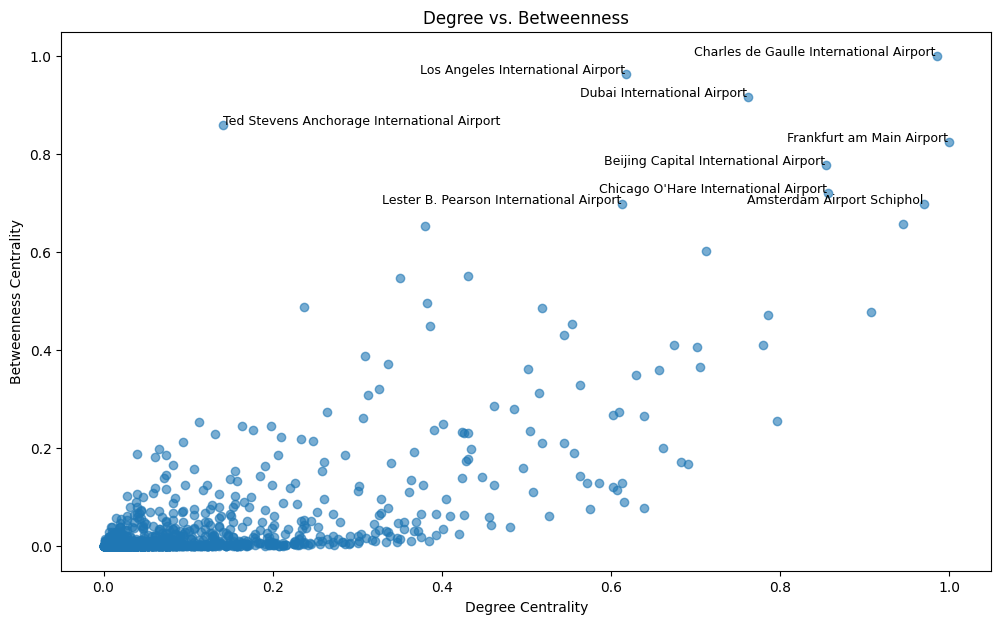

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.scatter(x='degree', y='betweenness', data=df_norm, alpha=0.6)


for i in range(len(df_norm)):
    if df_norm['betweenness'].iloc[i] > 0.67:
        if df_norm['airport_name'].iloc[i] == "Ted Stevens Anchorage International Airport":
            plt.text(df_norm['degree'].iloc[i] + 0.001,
                    df_norm['betweenness'].iloc[i] + 0.001,
                    df_norm['airport_name'].iloc[i],
                    fontsize=9,
                    ha='left')
        else:
            plt.text(df_norm['degree'].iloc[i] - 0.001,
                    df_norm['betweenness'].iloc[i] + 0.001,
                    df_norm['airport_name'].iloc[i],
                fontsize=9,
                ha='right')

plt.title("Degree vs. Betweenness")
plt.xlabel("Degree Centrality")
plt.ylabel("Betweenness Centrality")
plt.show()

In [80]:
# Hranica pre horné 1 %
threshold = df_norm['degree'].quantile(0.99)
top_1_percent = df_norm[df_norm['degree'] >= threshold]

In [71]:
df_norm['bridge_index'] = df_norm['betweenness'] / (df_norm['degree'] + 0.001)

df_norm['regional_index'] = df_norm['degree'] - df_norm['betweenness']

df_norm['prestige_index'] = df_norm['eigenvector'] / (df_norm['degree'] + 0.001)

df_norm['local_giant_index'] = df_norm['degree'] - df_norm['eigenvector']

cols_to_sum = ['degree', 'betweenness', 'closeness', 'eigenvector', 'katz']
df_norm['global_hub_score'] = df_norm[cols_to_sum].mean(axis=1)


In [74]:
global_hubs = df_norm.sort_values('global_hub_score', ascending=False)
global_hubs["airport_name"].head(10)

628     Charles de Gaulle International Airport
191                   Frankfurt am Main Airport
282                  Amsterdam Airport Schiphol
770               Atatürk International Airport
1017                Dubai International Airport
255                     London Heathrow Airport
1642      Beijing Capital International Airport
1885       Chicago O'Hare International Airport
196                              Munich Airport
1715          Los Angeles International Airport
Name: airport_name, dtype: object

In [75]:
global_hubs["country"] = global_hubs["airport_name"].map(
    dict(zip(nodes[" name"], nodes[" country"]))
)
global_hubs["continent"] = global_hubs.apply(lambda row: get_continent(
    latitude=nodes.loc[nodes[" name"] == row["airport_name"], " latitude"].values[0],
    longitude=nodes.loc[nodes[" name"] == row["airport_name"], " longitude"].values[0]
), axis=1)
global_hubs[["airport_name", "continent", "global_hub_score"]][:100].continent.value_counts()

continent
Europe                 48
North America          25
Asia                   16
Africa                  8
South America           2
Australia / Oceania     1
Name: count, dtype: int64

In [76]:
top_10_bridges = df_norm.sort_values('bridge_index', ascending=False)
top_10_bridges["airport_name"].head(10)

1861    Ted Stevens Anchorage International Airport
3058                                 Minaçu Airport
73                              Thunder Bay Airport
464                   Bangoka International Airport
2292                            Fort Albany Airport
96                             Norman Wells Airport
8                             Kangerlussuaq Airport
57                                 Moosonee Airport
3126                               Redenção Airport
3052                                 Gurupi Airport
Name: airport_name, dtype: object

In [78]:
top_10_bridges["continent"] = top_10_bridges.apply(lambda row: get_continent(
    latitude=nodes.loc[nodes[" name"] == row["airport_name"], " latitude"].values[0],
    longitude=nodes.loc[nodes[" name"] == row["airport_name"], " longitude"].values[0]
), axis=1)
top_10_bridges["continent"][:100].value_counts()

continent
North America          52
Australia / Oceania    16
South America          12
Africa                 10
Europe                  5
Asia                    3
Unknown continent       2
Name: count, dtype: int64

In [79]:
top_regional_centers = df_norm.sort_values('regional_index', ascending=False)
top_regional_centers["airport_name"].head(10)

279             London Stansted Airport
196                      Munich Airport
195                  Düsseldorf Airport
253              London Gatwick Airport
570     Barcelona International Airport
728        Vienna International Airport
242                  Manchester Airport
184                    Brussels Airport
288                      Dublin Airport
1990          Palma De Mallorca Airport
Name: airport_name, dtype: object

In [24]:
top_regional_centers["country"] = top_regional_centers["airport_name"].map(
    dict(zip(nodes[" name"], nodes[" country"]))
)
top_regional_centers["continent"] = top_regional_centers.apply(lambda row: get_continent(
    latitude=nodes.loc[nodes[" name"] == row["airport_name"], " latitude"].values[0],
    longitude=nodes.loc[nodes[" name"] == row["airport_name"], " longitude"].values[0]
), axis=1)

top_regional_centers[["airport_name", "continent", "regional_index"]][:100].continent.value_counts()

continent
Europe           56
North America    24
Asia             15
Africa            5
Name: count, dtype: int64

In [80]:
prestigious_gates = df_norm.sort_values('prestige_index', ascending=False)
prestigious_gates["airport_name"].head(10)

660                              Filippos Airport
698                               Bolzano Airport
583                             Salamanca Airport
2889                               Burgos Airport
2888                                 Leon Airport
3173                            Kastamonu Airport
2622                           Nakhchivan Airport
2478       Süleyman Demirel International Airport
745     Mihail Kogălniceanu International Airport
3168                                Zafer Airport
Name: airport_name, dtype: object

In [26]:
prestigious_gates["country"] = prestigious_gates["airport_name"].map(
    dict(zip(nodes[" name"], nodes[" country"]))
)
prestigious_gates["continent"] = prestigious_gates.apply(lambda row: get_continent(
    latitude=nodes.loc[nodes[" name"] == row["airport_name"], " latitude"].values[0],
    longitude=nodes.loc[nodes[" name"] == row["airport_name"], " longitude"].values[0]
), axis=1)
prestigious_gates["continent"][:100].value_counts()


continent
Europe               74
North America        20
Africa                3
Asia                  2
Unknown continent     1
Name: count, dtype: int64

In [81]:
top_local_giants = df_norm.sort_values('local_giant_index', ascending=False)
top_local_giants["airport_name"].head(10)

1809    Hartsfield Jackson Atlanta International Airport
1853                        Denver International Airport
1800             Dallas Fort Worth International Airport
1646              Guangzhou Baiyun International Airport
1642               Beijing Capital International Airport
2016                    Domodedovo International Airport
1885                Chicago O'Hare International Airport
1744        George Bush Intercontinental Houston Airport
1658             Kunming Changshui International Airport
1671             Chengdu Shuangliu International Airport
Name: airport_name, dtype: object

In [28]:
top_local_giants["country"] = top_local_giants["airport_name"].map(
    dict(zip(nodes[" name"], nodes[" country"]))
)
top_local_giants[["airport_name", "country", "local_giant_index"]][:100].country.value_counts()

country
China                   33
United States           24
Australia                4
Brazil                   4
India                    3
United Arab Emirates     2
Japan                    2
Mexico                   2
Thailand                 2
Iran                     2
Indonesia                2
Russia                   2
Singapore                1
Malaysia                 1
Argentina                1
United Kingdom           1
Philippines              1
Hong Kong                1
Taiwan                   1
Saudi Arabia             1
Turkey                   1
South Korea              1
South Africa             1
Colombia                 1
Panama                   1
New Zealand              1
Papua New Guinea         1
Kenya                    1
French Polynesia         1
Peru                     1
Name: count, dtype: int64

In [29]:
correlation_matrix = df[['degree', 'betweenness', 'closeness', 'eigenvector', 'katz']].corr(method='spearman')
print(correlation_matrix)

               degree  betweenness  closeness  eigenvector      katz
degree       1.000000     0.774729   0.732372     0.762203  0.973376
betweenness  0.774729     1.000000   0.479852     0.489583  0.710710
closeness    0.732372     0.479852   1.000000     0.967628  0.837815
eigenvector  0.762203     0.489583   0.967628     1.000000  0.862817
katz         0.973376     0.710710   0.837815     0.862817  1.000000
